<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/standford.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Decend - example

In [98]:
def func(x):
  return 3*x**2 -5*x+5

In [99]:
func(100)

29505

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([105.    ,  96.4375,  88.25  ,  80.4375,  73.    ,  65.9375,
         59.25  ,  52.9375,  47.    ,  41.4375,  36.25  ,  31.4375,
         27.    ,  22.9375,  19.25  ,  15.9375,  13.    ,  10.4375,
          8.25  ,   6.4375,   5.    ,   3.9375,   3.25  ,   2.9375,
          3.    ,   3.4375,   4.25  ,   5.4375,   7.    ,   8.9375,
         11.25  ,  13.9375,  17.    ,  20.4375,  24.25  ,  28.4375,
         33.    ,  37.9375,  43.25  ,  48.9375]))

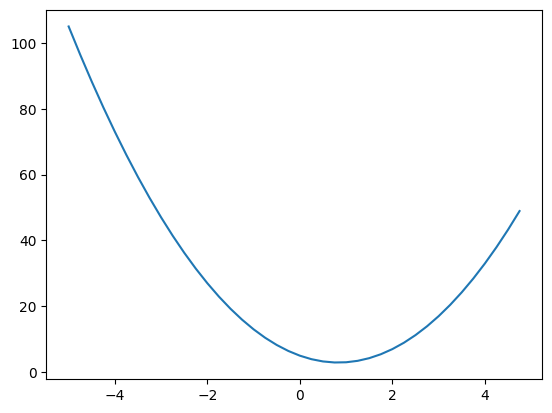

In [100]:
xs=np.arange(-5,5,0.25)
xs
ys = func(xs)
plt.plot(xs,ys)
xs ,ys

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([105.    ,  96.4375,  88.25  ,  80.4375,  73.    ,  65.9375,
         59.25  ,  52.9375,  47.    ,  41.4375,  36.25  ,  31.4375,
         27.    ,  22.9375,  19.25  ,  15.9375,  13.    ,  10.4375,
          8.25  ,   6.4375,   5.    ,   3.9375,   3.25  ,   2.9375,
          3.    ,   3.4375,   4.25  ,   5.4375,   7.    ,   8.9375,
         11.25  ,  13.9375,  17.    ,  20.4375,  24.25  ,  28.4375,
         33.    ,  37.9375,  43.25  ,  48.9375]),
 array([104.98250075,  96.42075075,  88.23400075,  80.42225075,
         72.98550075,  65.92375075,  59.23700075,  52.92525075,
         46.98850075,  41.42675075,  36.24000075,  31.42825075,
         26.99150075,  22.92

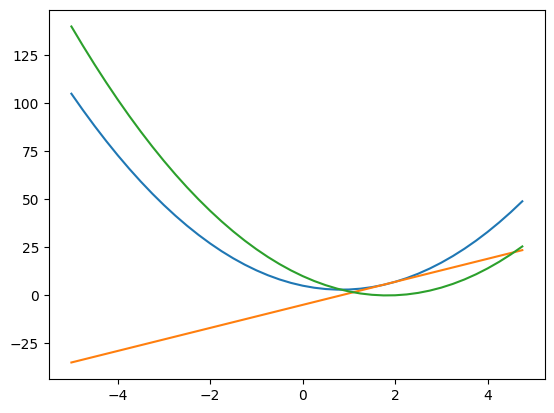

In [101]:
h = 0.0005
k = (func(xs+h) -func(xs))/h

dl = func(xs) - k
plt.plot(xs, func(xs+h))
plt.plot(xs, k)

plt.plot(xs, dl)

xs, func(xs),func(xs+h),k, dl

In [102]:
a=5
b=6
c=8
d = a*b+c
d

38

# Example of grdient - local and global

In [103]:
class Value:
  def __init__(self, val1, _child=(), _op='', label=''):
    self.data = val1
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_child)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(label={self.label}, data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    # Topological sort to order the nodes
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    # Go backwards through the sorted list
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(131, label='a')
b = Value(151, label='b')
c = Value(161, label='c')

d = a*b; d.label = 'd'
e = d+c; e.label = 'e'
f = e*a; f.label = 'f'
L = f+c; L.label = 'L'
#(a*b+c)*a+c

# Corrected attribute access from .prev to ._prev
print(a.data, b.data, c.data, d.data, e.data, f.data, L.data)
print(a._prev, b._prev, c._prev, d._prev, e._prev, f._prev, L._prev)
print(a._op, b._op, c._op, d._op, e._op, f._op, L._op)
print(a.label, b.label, c.label, d.label, e.label, f.label, L.label)

131 151 161 19781 19942 2612402 2612563
set() set() set() {Value(label=a, data=131), Value(label=b, data=151)} {Value(label=c, data=161), Value(label=d, data=19781)} {Value(label=a, data=131), Value(label=e, data=19942)} {Value(label=c, data=161), Value(label=f, data=2612402)}
   * + * +
a b c d e f L


In [104]:
e._prev, d._prev, e._op, d._op
# d

({Value(label=c, data=161), Value(label=d, data=19781)},
 {Value(label=a, data=131), Value(label=b, data=151)},
 '+',
 '*')

In [105]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    label_str = f"{n.label} | data {n.data:.4f} | grad {n.grad:.4f}"
    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

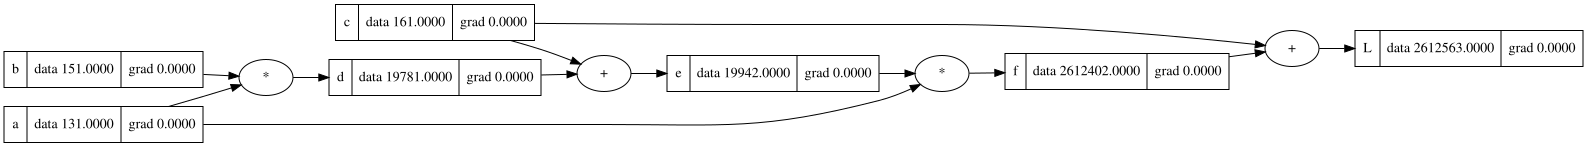

In [106]:
draw_dot(L)

### Why 'f' and 'd' both matter
Look at the graph below. Notice that `a` has two outgoing edges:
1. One goes to `d` (multiplied by `b`)
2. One goes to `f` (multiplied by `e`)

Because `a` is a direct input to both `d` and `f`, its total influence on `L` must account for both connections.

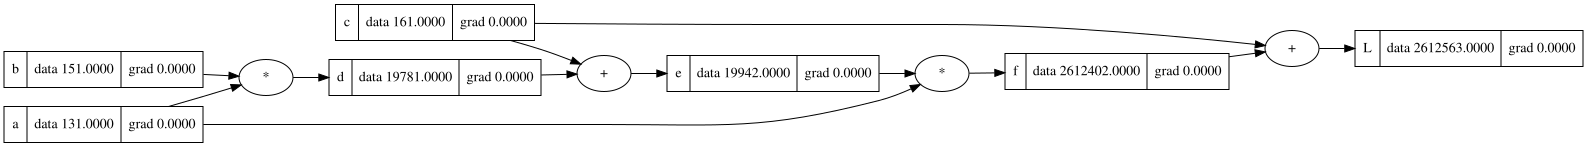

In [107]:
draw_dot(L)

In [108]:
def loc():
  h = 0.001

  # First run: normal values
  a = Value(131.0, label='a')
  b = Value(151.0, label='b')
  c = Value(161.0, label='c')
  d = a*b; d.label = 'd'
  e = d+c; e.label = 'e'
  f = e*a; f.label = 'f'
  L = f+c; L.label = 'L'
  L1 = f.data

  # Second run: nudge 'a' BEFORE calculating the dependent variables
  a = Value(131.0, label='a')
  b = Value(151.0, label='b')
  c = Value(161.0, label='c')

  a.data += h # Nudge input first

  d = a*b; d.label = 'd'
  # d.data += h # Nudge input first

  e = d+c; e.label = 'e'
  # e.data += h # Nudge input first

  f = e*a; f.label = 'f'
  # f.data += h # Nudge input first

  L = f+c; L.label = 'L'
  L2 = f.data

  return L1, L2, (L2-L1)/h

loc()

(2612402.0, 2612441.723151, 39723.1510002166)

In [109]:
f.grad = 1
c.grad = 132.00000021606684
a.grad=39723.1510002166 #dd/da = 151.00000000165892;df/da=39723.1510002166
b.grad=17161.000000312924
d.grad =131.00000005215406
e.grad=131.00000005215406

# if we know wvery node data, we can get a local grad, but we actually need global grad that is with respect to dl
# and that node, so we finally multiply all the local grad to get it


In [110]:
# Let's calculate the two separate components of a's gradient
# Expression: L = ((a * b + c) * a) + c

# 1. Gradient of a through the path of 'd'
# d = a * b -> dd/da = b
grad_a_path_1 = b.data

# 2. Gradient of a through the direct path to 'f'
# f = e * a -> df/da = e
grad_a_path_2 = e.data

print(f"Local grad from d: {grad_a_path_1}")
print(f"Local grad from f: {grad_a_path_2}")
print(f"Total sensitivity: {grad_a_path_1 + grad_a_path_2}")

Local grad from d: 151
Local grad from f: 19942
Total sensitivity: 20093


### Verifying the Total Gradient for 'a'
Based on the chain rule, we will manually apply the gradients from the output `L` backwards.
Remember: `L = f + c`, so `dL/df = 1` and `dL/dc = 1`.

Manual Backprop a.grad: 39723.0
Earlier Nudge Test result: ~39723


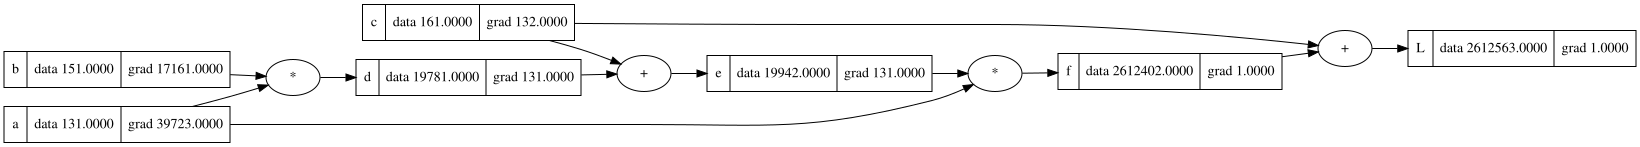

In [111]:
# 1. Initialize top-level gradient
L.grad = 1.0

# 2. Backprop through L = f + c
f.grad = 1.0 * L.grad
c.grad = 1.0 * L.grad

# 3. Backprop through f = e * a
# df/de = a, df/da = e
e.grad = a.data * f.grad
# Note: we use += for 'a' because it will receive gradients from elsewhere too!
a.grad = e.data * f.grad

# 4. Backprop through e = d + c
# de/dd = 1, de/dc = 1
d.grad = 1.0 * e.grad
c.grad += 1.0 * e.grad # c also appears twice!

# 5. Backprop through d = a * b
# dd/da = b, dd/db = a
a.grad += b.data * d.grad # ACCUMULATING gradient from the second path
b.grad = a.data * d.grad

print(f"Manual Backprop a.grad: {a.grad}")
print(f"Earlier Nudge Test result: ~39723")
draw_dot(L)

### The Multivariate Chain Rule
If a variable (like `a`) flows into multiple paths in the graph, its total gradient is the **sum** of the gradients from each path.

$$\frac{\partial L}{\partial a} = \sum_{i} \frac{\partial L}{\partial path_i} \cdot \frac{\partial path_i}{\partial a}$$

In our case:
`a.grad = (dL/df * df/da) + (dL/df * df/de * de/dd * dd/da)`

Automated a.grad: 39723.0


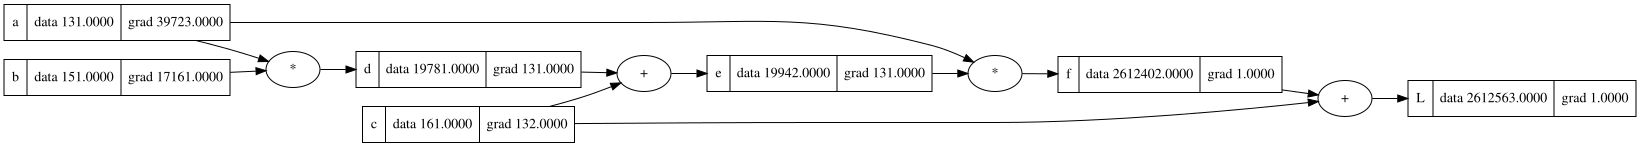

In [112]:
# 1. Re-initialize the graph
a = Value(131.0, label='a')
b = Value(151.0, label='b')
c = Value(161.0, label='c')
d = a * b; d.label = 'd'
e = d + c; e.label = 'e'
f = e * a; f.label = 'f'
L = f + c; L.label = 'L'

# 2. Run the automated backpropagation
L.backward()

# 3. Verify results
print(f"Automated a.grad: {a.grad}")
draw_dot(L)

### Mathematical Verification of `a.grad` and `c.grad`

Let's use the local derivatives you listed and apply the chain rule properly by multiplying by the upstream gradients:

**For c:**
- Path 1: $L \to c \implies \frac{\partial L}{\partial c} = 1$
- Path 2: $L \to f \to e \to c \implies \frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial e} \cdot \frac{\partial e}{\partial c} = 1 \cdot a \cdot 1 = a$
- Total $\frac{\partial L}{\partial c} = 1 + a$

**For a:**
- Path 1 (Direct to f): $\frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial a} = 1 \cdot e$
- Path 2 (Through d): $\frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial e} \cdot \frac{\partial e}{\partial dd} \cdot \frac{\partial d}{\partial a} = 1 \cdot a \cdot 1 \cdot b$
- Total $\frac{\partial L}{\partial a} = e + (a \cdot b)$

In [113]:
# Using the values from the previous cell
a_val = 131.0
b_val = 151.0
c_val = 161.0
d_val = a_val * b_val
e_val = d_val + c_val

# Calculate gradients based on the multivariate chain rule derivation above
grad_c = 1 + a_val
grad_a = e_val + (a_val * b_val)

print(f"Calculated c.grad: {grad_c}")
print(f"Calculated a.grad: {grad_a}")
print(f"Matches automated backprop? {grad_a == a.grad}")

Calculated c.grad: 132.0
Calculated a.grad: 39723.0
Matches automated backprop? True


### Inspecting Internal State

Each `Value` object maintains its own internal state. When we perform an operation like `d = a * b`, a **new** `Value` object is created for `d`, which holds references to its parents (`a` and `b`) in its `_prev` set.

When we call `backward()`, it finds every unique `Value` object and updates its specific `grad` attribute.

In [114]:
# Let's look at the internal dictionary of our variables
print("Internal state of 'a':")
display(a.__dict__)

print("\nInternal state of 'd' (the product of a and b):")
display(d.__dict__)

# Note how 'd' stores 'a' and 'b' in '_prev' to remember the graph structure

Internal state of 'a':


{'data': 131.0,
 'grad': 39723.0,
 '_backward': <function __main__.Value.__init__.<locals>.<lambda>()>,
 '_prev': set(),
 '_op': '',
 'label': 'a'}


Internal state of 'd' (the product of a and b):


{'data': 19781.0,
 'grad': 131.0,
 '_backward': <function __main__.Value.__mul__.<locals>._backward()>,
 '_prev': {Value(label=a, data=131.0), Value(label=b, data=151.0)},
 '_op': '*',
 'label': 'd'}

### Local vs. Global Gradients

| Term | Where is it? | What is it? |
| :--- | :--- | :--- |
| **Local Gradient** | Inside `_backward()` | The derivative of an output with respect to its immediate input (e.g., in `a*b`, it's just `b`). |
| **Global Gradient** | `self.grad` | The derivative of the final result `L` with respect to this node, calculated by multiplying the local grad by the upstream grad. |

In [115]:
# To prove it, notice that even if 'd' is very large (19781),
# its grad (131) is relative to 'L', not relative to its inputs.

print(f"Value of d: {d.data}")
print(f"Global Gradient of d (dL/dd): {d.grad}")
print("Note that d.grad is exactly 'a', because L = (d+c)*a + c, and dL/dd = a.")

Value of d: 19781.0
Global Gradient of d (dL/dd): 131.0
Note that d.grad is exactly 'a', because L = (d+c)*a + c, and dL/dd = a.


# tanh + recursive function of child tracing

[]

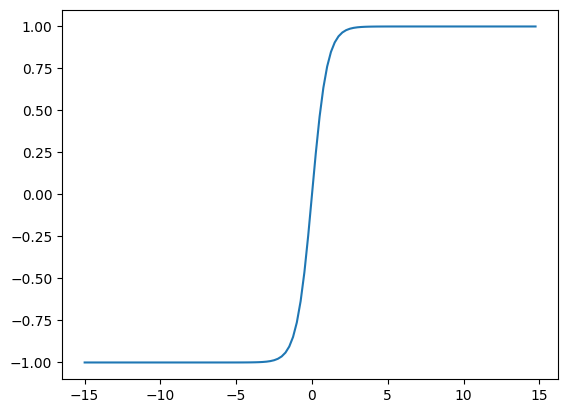

In [116]:
plt.plot(np.arange(-15,15,0.25), np.tanh(np.arange(-15,15,0.25)));plt.plot()
# print(np.arange(-15,15,0.25))

In [117]:
import numpy as np

class neuron:
  def __init__(self, w_data, _track=(), _op='', label=''):
    self.wt_data = w_data
    self.label = str(w_data) if not label else label
    self.track = set(_track)
    self._op = _op
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"{self.label}"

  def __mul__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    mul_out = neuron(self.wt_data * others.wt_data, (self, others), '*', label=f"({self.label}*{others.label})")
    def _backward():
      self.grad += others.wt_data * mul_out.grad
      others.grad += self.wt_data * mul_out.grad
    mul_out._backward = _backward
    return mul_out

  def __rmul__(self, others):
    return self * others

  def __add__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    add_out = neuron(self.wt_data + others.wt_data, (self, others), '+', label=f"({self.label}+{others.label})")
    def _backward():
      self.grad += 1.0 * add_out.grad
      others.grad += 1.0 * add_out.grad
    add_out._backward = _backward
    return add_out

  def __radd__(self, others):
    return self + others

  def __sub__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    sub_out = neuron(self.wt_data - others.wt_data, (self, others), '-', label=f"({self.label}-{others.label})")
    def _backward():
      self.grad += 1.0 * sub_out.grad
      others.grad += -1.0 * sub_out.grad
    sub_out._backward = _backward
    return sub_out

  def __rsub__(self, others):
    return neuron(others) - self

  def __neg__(self):
    return self * -1

  def tanh(self):
    x = self.wt_data
    t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
    tan_out = neuron(t, (self, ), 'tanh', label=f"tanh({self.label})")
    def _backward():
      self.grad += (1 - (t**2)) * tan_out.grad
    tan_out._backward = _backward
    return tan_out

  def exp(self):
    exp_out = neuron(np.exp(self.wt_data), (self,), 'exp', label=f"exp({self.label})")
    def _backward():
      self.grad += exp_out.wt_data * exp_out.grad
    exp_out._backward = _backward
    return exp_out

  def __pow__(self, others):
    assert isinstance(others, (int, float)), "Only supporting int/float powers"
    pow_out = neuron(self.wt_data**others, (self,), 'pow', label=f"({self.label}**{others})")
    def _backward():
      self.grad += (others * (self.wt_data**(others - 1))) * pow_out.grad
    pow_out._backward = _backward
    return pow_out

  def __truediv__(self, others):
    return self * (others**-1)

  def __rtruediv__(self, others):
    return others * (self**-1)

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v.track:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    print(topo)
    self.grad = 1.0
    for nodes in reversed(topo):
      nodes._backward()

# Instantiate and run automated backward
w1 = neuron(1.0, label='w1')
x1 = neuron(3.0, label='x1')
b = neuron(1.0, label='b')
w2 = neuron(-1.0, label='w2')
x2 = neuron(3.0, label='x2')

w1x1 = w1*x1; w1x1.label = 'w1*x1'
w2x2 = w2*x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1+w2x2; w1x1w2x2.label = 'w1x1+w2x2'
w1x1w2x2b = w1x1w2x2+b; w1x1w2x2b.label = 'w1x1+w2x2+b'
# tan_h = w1x1w2x2b.tanh(); tan_h.label = 'tan_h'



In [118]:
# @title
from graphviz import Digraph

def neu_trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v.track:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot_n(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = neu_trace(root)
  for n in nodes:
    uid = str(id(n))
    label_str = f"{n.label} | data {n.wt_data:.4f} | grad {n.grad:.4f}"
    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

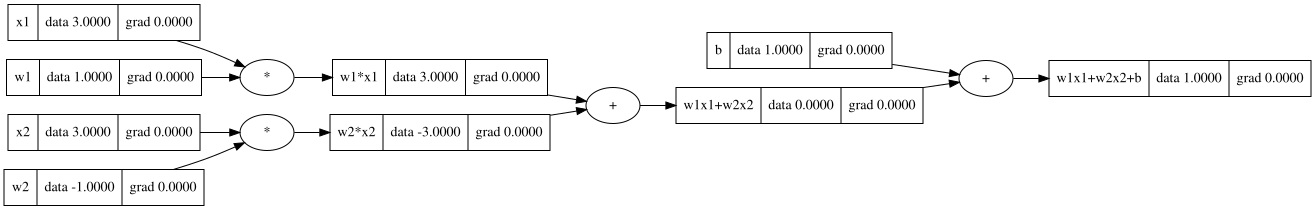

In [119]:
# @title
draw_dot_n(w1x1w2x2b)
# draw_dot_n(w1w1)


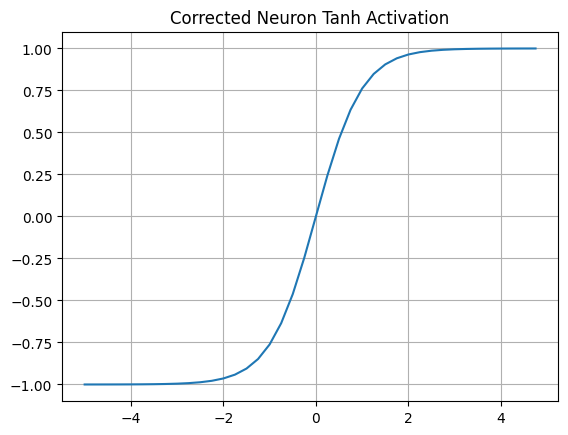

In [120]:
# @title
a = np.arange(-5, 5, 0.25)
results = np.zeros_like(a)

for idx, i in enumerate(a):
    n = neuron(i)
    res = n.tanh()
    results[idx] = res.wt_data

plt.plot(a, results)
plt.title("Corrected Neuron Tanh Activation")
plt.grid(True)
plt.show()

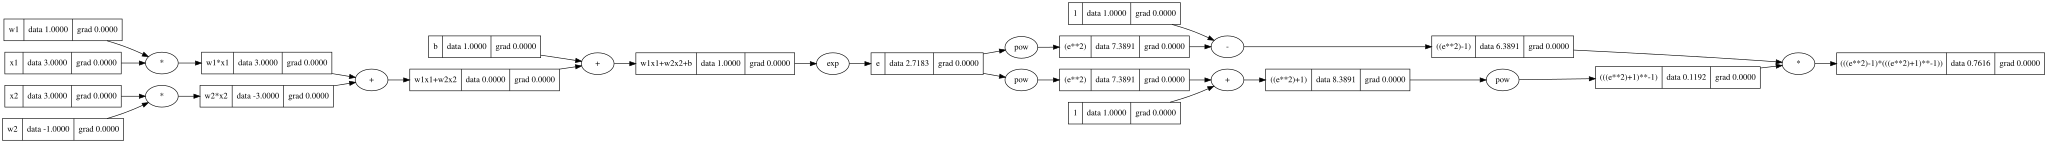

In [121]:
# To fix the error, call the .exp() method on the neuron instance itself
e = w1x1w2x2b.exp(); e.label = 'e'
tanh = (e**2 - 1)/(e**2 + 1);tanh.lebel = 'tanh'
draw_dot_n(tanh)
# print(s)

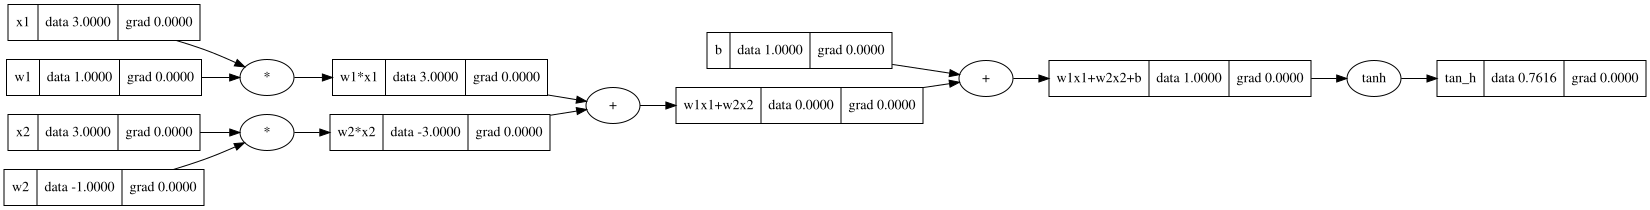

In [122]:
tan_h = w1x1w2x2b.tanh(); tan_h.label = 'tan_h'
draw_dot_n(tan_h)

In [123]:
# @title
print(f"Manual tanh calculation (Cell 45): {tanh.wt_data}")
print(f"Built-in .tanh() method (Cell 46): {tan_h.wt_data}")

# Check for equality with a small epsilon for floating point precision
match = np.isclose(tanh.wt_data, tan_h.wt_data)
print(f"\nDo the values match? {match}")

Manual tanh calculation (Cell 45): 0.761594155955765
Built-in .tanh() method (Cell 46): 0.7615941559557649

Do the values match? True


In [124]:
# tan_h.grad = 1.0
tanh.backward()
# print(tanh.backward())

[w1, x1, w1*x1, x2, w2, w2*x2, w1x1+w2x2, b, w1x1+w2x2+b, e, (e**2), 1, ((e**2)-1), 1, (e**2), ((e**2)+1), (((e**2)+1)**-1), (((e**2)-1)*(((e**2)+1)**-1))]


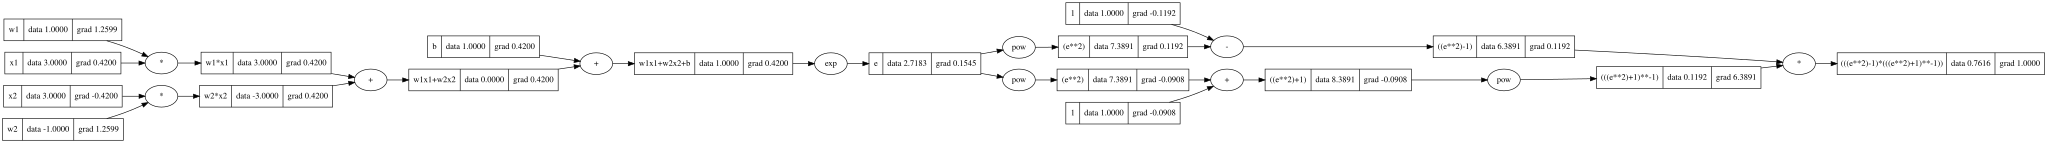

In [125]:
draw_dot_n(tanh)

[w1, x1, w1*x1, x2, w2, w2*x2, w1x1+w2x2, b, w1x1+w2x2+b, tan_h]


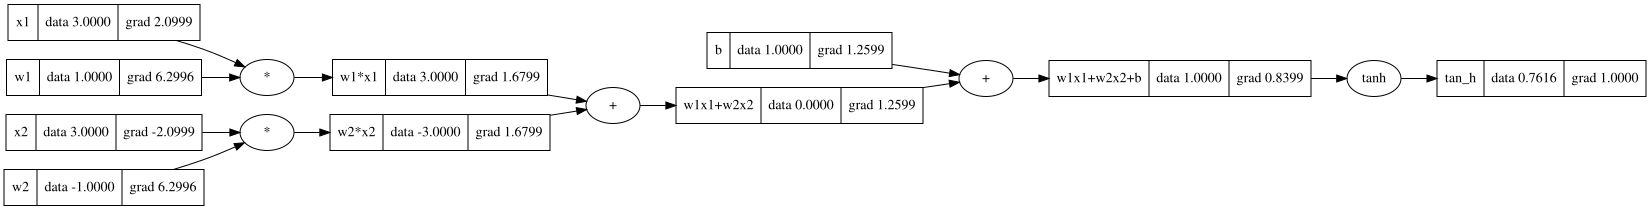

In [126]:
tan_h.backward()
draw_dot_n(tan_h)

In [127]:
def reset_all_grads():
    # Helper to find all nodes in a graph and reset them
    def get_all_nodes(root):
        nodes = set()
        def build(v):
            if v not in nodes:
                nodes.add(v)
                for child in v.track:
                    build(child)
        build(root)
        return nodes

    all_nodes = get_all_nodes(tanh) | get_all_nodes(tan_h)
    for n in all_nodes:
        n.grad = 0.0

# Re-define variables to ensure fresh graph state
w1 = neuron(1.0, label='w1')
x1 = neuron(3.0, label='x1')
b = neuron(1.0, label='b')
w2 = neuron(-1.0, label='w2')
x2 = neuron(3.0, label='x2')

# Basic linear combo
n = w1*x1 + w2*x2 + b

# 1. Atomic Method
print("--- Topo for Atomic Method ---")
tan_h = n.tanh()
tan_h.backward()
grad_atomic = { 'w1': w1.grad, 'x1': x1.grad, 'b': b.grad }

# 2. Manual Composite Tanh: (e^(2x) - 1) / (e^(2x) + 1)
print("\n--- Topo for Manual Composite ---")
w1.grad, x1.grad, b.grad = 0, 0, 0
e2x = (2 * n).exp()
tanh = (e2x - 1) / (e2x + 1)
tanh.backward()
grad_manual = { 'w1': w1.grad, 'x1': x1.grad, 'b': b.grad }

print("\n--- Gradient Comparison ---")
print(f"Manual Composite: {grad_manual}")
print(f"Atomic Method:    {grad_atomic}")

--- Topo for Atomic Method ---
[x1, w1, (w1*x1), w2, x2, (w2*x2), ((w1*x1)+(w2*x2)), b, (((w1*x1)+(w2*x2))+b), tanh((((w1*x1)+(w2*x2))+b))]

--- Topo for Manual Composite ---
[1, x1, w1, (w1*x1), w2, x2, (w2*x2), ((w1*x1)+(w2*x2)), b, (((w1*x1)+(w2*x2))+b), 2, ((((w1*x1)+(w2*x2))+b)*2), exp(((((w1*x1)+(w2*x2))+b)*2)), (exp(((((w1*x1)+(w2*x2))+b)*2))-1), 1, (exp(((((w1*x1)+(w2*x2))+b)*2))+1), ((exp(((((w1*x1)+(w2*x2))+b)*2))+1)**-1), ((exp(((((w1*x1)+(w2*x2))+b)*2))-1)*((exp(((((w1*x1)+(w2*x2))+b)*2))+1)**-1))]

--- Gradient Comparison ---
Manual Composite: {'w1': np.float64(5.039692099368313), 'x1': np.float64(1.6798973664561045), 'b': np.float64(0.839948683228052)}
Atomic Method:    {'w1': np.float64(1.2599230248420783), 'x1': np.float64(0.41997434161402614), 'b': np.float64(0.41997434161402614)}


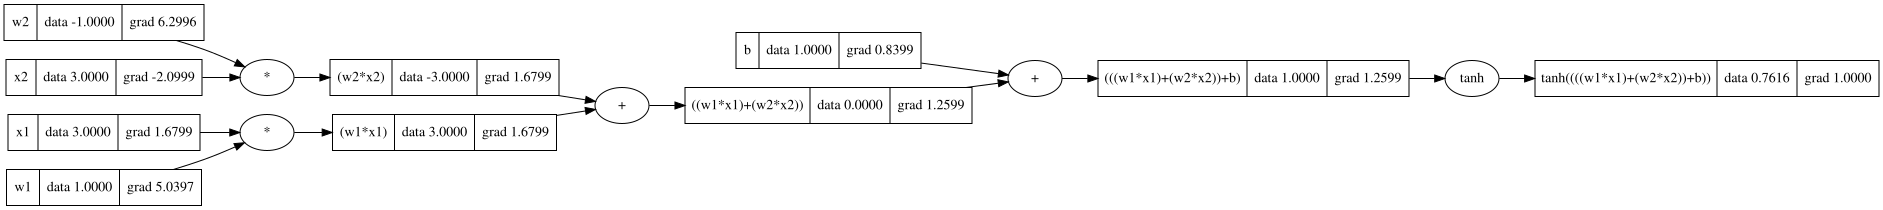

In [128]:
tan_h.grad = 1.0
tan_h._backward()
w1x1w2x2b._backward()
w1x1w2x2._backward()
w1x1._backward()
w2x2._backward()
draw_dot_n(tan_h)

In [129]:
tan_h.grad=1
w1x1w2x2b.grad = (1-(tan_h.wt_data)**2) * tan_h.grad
w1x1w2x2.grad = (1)*w1x1w2x2b.grad
b.grad = (1)*w1x1w2x2b.grad
w2x2.grad = (1)*w1x1w2x2.grad
w1x1.grad = (1)*w1x1w2x2.grad
w1.grad=x1.wt_data * w1x1.grad
x1.grad=w1.wt_data * w1x1.grad
w2.grad=x2.wt_data * w2x2.grad
x2.grad=w2.wt_data * w2x2.grad

Same stuff, AI did it

In [130]:
import numpy as np

class neuron:
  _all_neurons = [] # Class-level list to store all neuron instances

  def __init__(self, w_data, _track=(), _op='', label=''):
    self.wt_data = w_data
    self.label = label
    self.track = set(_track)
    self._op = _op
    self.grad = 0.0
    self._backward = lambda: None
    neuron._all_neurons.append(self) # Add self to the list of all neurons

  def __repr__(self):
    return f"Neuron(label={self.label}, weight={self.wt_data})"

  def __mul__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    mul_out = neuron(self.wt_data * others.wt_data, (self, others), '*')
    def _backward():
      self.grad += others.wt_data * mul_out.grad
      others.grad += self.wt_data * mul_out.grad
    mul_out._backward = _backward
    return mul_out

  def __add__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    add_out = neuron(self.wt_data + others.wt_data, (self, others), '+')
    def _backward():
      self.grad += 1.0 * add_out.grad
      others.grad += 1.0 * add_out.grad
    add_out._backward = _backward
    return add_out

  def tanh(self):
    x = self.wt_data
    t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
    tan_out = neuron(t, (self, ), 'tanh', label='tanh')
    def _backward():
      self.grad += (1 - (tan_out.wt_data**2)) * tan_out.grad
    tan_out._backward = _backward
    return tan_out

  def backward(self):
    # 1. Build the topological sort
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v.track:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    # 2. Initialize the global gradient to 1.0
    self.grad = 1.0

    # 3. Apply the backward logic in reverse order
    for node in reversed(topo):
      node._backward()

# Clear the list before instantiating new neurons to avoid duplicates from previous runs
neuron._all_neurons.clear()

# Instantiate and run automated backward
w1 = neuron(1.0, label='w1')
x1 = neuron(3.0, label='x1')
b = neuron(1.0, label='b')
w2 = neuron(-1.0, label='w2')
x2 = neuron(3.0, label='x2')

w1x1 = w1*x1; w1x1.label = 'w1*x1'
w2x2 = w2*x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1+w2x2; w1x1w2x2.label = 'w1x1+w2x2'
w1x1w2x2b = w1x1w2x2+b; w1x1w2x2b.label = 'w1x1+w2x2+b'
tan_h = w1x1w2x2b.tanh(); tan_h.label = 'tan_h'

tan_h.backward()

print(f"Gradient of b: {b.grad}")
print(f"Gradient of w1: {w1.grad}")

Gradient of b: 0.41997434161402614
Gradient of w1: 1.2599230248420783


In [131]:
print(f"Total number of nodes stored globally: {len(neuron._all_neurons)}")
print("\nInformation for each globally stored node:")
for node in neuron._all_neurons:
  print(node)

Total number of nodes stored globally: 10

Information for each globally stored node:
Neuron(label=w1, weight=1.0)
Neuron(label=x1, weight=3.0)
Neuron(label=b, weight=1.0)
Neuron(label=w2, weight=-1.0)
Neuron(label=x2, weight=3.0)
Neuron(label=w1*x1, weight=3.0)
Neuron(label=w2*x2, weight=-3.0)
Neuron(label=w1x1+w2x2, weight=0.0)
Neuron(label=w1x1+w2x2+b, weight=1.0)
Neuron(label=tan_h, weight=0.7615941559557649)


In [132]:
print(f"Total number of nodes stored globally: {len(neuron._all_neurons)}")
print("\nInformation for each globally stored node:")
for node in neuron._all_neurons:
  print(node)

Total number of nodes stored globally: 10

Information for each globally stored node:
Neuron(label=w1, weight=1.0)
Neuron(label=x1, weight=3.0)
Neuron(label=b, weight=1.0)
Neuron(label=w2, weight=-1.0)
Neuron(label=x2, weight=3.0)
Neuron(label=w1*x1, weight=3.0)
Neuron(label=w2*x2, weight=-3.0)
Neuron(label=w1x1+w2x2, weight=0.0)
Neuron(label=w1x1+w2x2+b, weight=1.0)
Neuron(label=tan_h, weight=0.7615941559557649)


In [133]:
print(f"Variable 'w1' points to memory address: {hex(id(w1))}")
print(f"Variable 'x1' points to memory address: {hex(id(x1))}")

# Even if they have the same data, they are different objects in memory
test_neuron = neuron(1.0, label='w1')
print(f"New instance with same data points to: {hex(id(test_neuron))}")

Variable 'w1' points to memory address: 0x79dabb20a300
Variable 'x1' points to memory address: 0x79dabb279e20
New instance with same data points to: 0x79dabae8c620


In [134]:
neuron._all_neurons.clear() # Clear existing neurons for a fresh start

# Create a neuron without a label initially
c_unlabeled = neuron(5.0)
print(f"Neuron created: {c_unlabeled!r}")

# Assign a label to it
c_unlabeled.label = 'c_from_prompt'
print(f"Neuron after labeling: {c_unlabeled!r}")

# You can also assign during initialization
c_labeled_init = neuron(10.0, label='c_init')
print(f"Neuron labeled at init: {c_labeled_init!r}")

Neuron created: Neuron(label=, weight=5.0)
Neuron after labeling: Neuron(label=c_from_prompt, weight=5.0)
Neuron labeled at init: Neuron(label=c_init, weight=10.0)


In [135]:
neuron._all_neurons.clear() # Clear existing neurons for a fresh start

# Define your input neurons
w1 = neuron(1.0, label='w1')
x1 = neuron(3.0, label='x1')
b = neuron(1.0, label='b')
w2 = neuron(-1.0, label='w2')
x2 = neuron(3.0, label='x2')

# Define the intermediate operations and label them
w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1 + w2x2; w1x1w2x2.label = 'w1x1+w2x2'
w1x1w2x2b = w1x1w2x2 + b; w1x1w2x2b.label = 'w1x1+w2x2+b'

# Final output neuron, if any
tan_h = w1x1w2x2b.tanh(); tan_h.label = 'tan_h'

print("Current neuron graph nodes:")
for n in neuron._all_neurons:
  print(f"- {n!r}")

Current neuron graph nodes:
- Neuron(label=w1, weight=1.0)
- Neuron(label=x1, weight=3.0)
- Neuron(label=b, weight=1.0)
- Neuron(label=w2, weight=-1.0)
- Neuron(label=x2, weight=3.0)
- Neuron(label=w1*x1, weight=3.0)
- Neuron(label=w2*x2, weight=-3.0)
- Neuron(label=w1x1+w2x2, weight=0.0)
- Neuron(label=w1x1+w2x2+b, weight=1.0)
- Neuron(label=tan_h, weight=0.7615941559557649)


# Pytorch

In [136]:
import torch

In [137]:
# @title
w1 = torch.Tensor([1.0]).double(); w1.requires_grad = True
x1 = torch.Tensor([3.0]).double(); x1.requires_grad = True
w2 = torch.Tensor([-1.0]).double(); w2.requires_grad = True
x2 = torch.Tensor([3.0]).double(); x2.requires_grad = True
b = torch.Tensor([1.0]).double();
o = w1*x1 + w2*x2 + b; o.retain_grad() # This allows us to access o.grad even though it is not a leaf node
o_active = torch.tanh(o)
o_active.backward()

print(f"Value of o: {o.data.item()}")
print(f"Value of x1: {x1.data.item()}")
print(f"Value of w1: {w1.data.item()}")
print(f"Value of x2: {x2.data.item()}")
print(f"Value of w2: {w2.data.item()}")

print(f"Gradient of o: {o.grad.item()}")
print(f"Gradient of x1: {x1.grad.item()}")
print(f"Gradient of w1: {w1.grad.item()}")
print(f"Gradient of x2: {x2.grad.item()}")
print(f"Gradient of w2: {w2.grad.item()}")

print(f"--------------------")
print(f"Value of o_active: {o_active.data.item()}")


Value of o: 1.0
Value of x1: 3.0
Value of w1: 1.0
Value of x2: 3.0
Value of w2: -1.0
Gradient of o: 0.41997434161402614
Gradient of x1: 0.41997434161402614
Gradient of w1: 1.2599230248420783
Gradient of x2: -0.41997434161402614
Gradient of w2: 1.2599230248420783
--------------------
Value of o_active: 0.7615941559557649


In [138]:
import numpy as np

class neuron:
  def __init__(self, w_data, _track=(), _op='', label=''):
    self.wt_data = w_data
    self.label = str(w_data) if not label else label
    self.track = set(_track)
    self._op = _op
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"{self.label}"

  def __mul__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    mul_out = neuron(self.wt_data * others.wt_data, (self, others), '*', label=f"({self.label}*{others.label})")
    def _backward():
      self.grad += others.wt_data * mul_out.grad
      others.grad += self.wt_data * mul_out.grad
    mul_out._backward = _backward
    return mul_out

  def __rmul__(self, others):
    return self * others

  def __add__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    add_out = neuron(self.wt_data + others.wt_data, (self, others), '+', label=f"({self.label}+{others.label})")
    def _backward():
      self.grad += 1.0 * add_out.grad
      others.grad += 1.0 * add_out.grad
    add_out._backward = _backward
    return add_out

  def __radd__(self, others):
    return self + others

  def __sub__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    sub_out = neuron(self.wt_data - others.wt_data, (self, others), '-', label=f"({self.label}-{others.label})")
    def _backward():
      self.grad += 1.0 * sub_out.grad
      others.grad += -1.0 * sub_out.grad
    sub_out._backward = _backward
    return sub_out

  def __rsub__(self, others):
    return neuron(others) - self

  def __neg__(self):
    return self * -1

  def tanh(self):
    x = self.wt_data
    t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
    tan_out = neuron(t, (self, ), 'tanh', label=f"tanh({self.label})")
    def _backward():
      self.grad += (1 - (t**2)) * tan_out.grad
    tan_out._backward = _backward
    return tan_out

  def exp(self):
    exp_out = neuron(np.exp(self.wt_data), (self,), 'exp', label=f"exp({self.label})")
    def _backward():
      self.grad += exp_out.wt_data * exp_out.grad
    exp_out._backward = _backward
    return exp_out

  def __pow__(self, others):
    assert isinstance(others, (int, float)), "Only supporting int/float powers"
    pow_out = neuron(self.wt_data**others, (self,), 'pow', label=f"({self.label}**{others})")
    def _backward():
      self.grad += (others * (self.wt_data**(others - 1))) * pow_out.grad
    pow_out._backward = _backward
    return pow_out

  def __truediv__(self, others):
    return self * (others**-1)

  def __rtruediv__(self, others):
    return others * (self**-1)

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v.track:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    print(topo)
    self.grad = 1.0
    for nodes in reversed(topo):
      nodes._backward()

# Instantiate and run automated backward
w1 = neuron(1.0, label='w1')
x1 = neuron(3.0, label='x1')
b = neuron(1.0, label='b')
w2 = neuron(-1.0, label='w2')
x2 = neuron(3.0, label='x2')

w1x1 = w1*x1; w1x1.label = 'w1*x1'
w2x2 = w2*x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1+w2x2; w1x1w2x2.label = 'w1x1+w2x2'
w1x1w2x2b = w1x1w2x2+b; w1x1w2x2b.label = 'w1x1+w2x2+b'
# tan_h = w1x1w2x2b.tanh(); tan_h.label = 'tan_h'



In [139]:
class nuemu:
  def __init__(self, n_neu=0):
    # This creates a list of neuron objects, each with a random weight
    self.w = [neuron(np.random.uniform(-1, 1)) for _ in range(n_neu)]
    # Assuming a single bias for the neuron, initialized randomly
    self.b = neuron(np.random.uniform(-1, 1))

  def __call__(self, num):
    # We calculate sum(wi * xi) + b
    # The square brackets [] create the list of products, then sum() adds them up
    act = sum([wi * xi for wi, xi in zip(self.w, num)], self.b)
    out = act.tanh()
    return out


x = [1, 5, 7]
n = nuemu(3)
out = n(x)

print(f"Weights: {n.w}")
print(f"inputs: {x}")
print(f"Bias: {n.b}")
print(f"Output: {out.wt_data}")

Weights: [0.823287895309937, 0.2653460510481289, 0.33691566203777157]
inputs: [1, 5, 7]
Bias: 0.1801331050710624
Output: 0.9998307374052867


In [140]:
class layer:
  def __init__(self, wt_n, neu_n):
    # wt_n: number of inputs per neuron
    # neu_n: number of neurons in this layer
    self.layer = [nuemu(wt_n) for _ in range(neu_n)]

  def __call__(self, x):
    out = [neu(x) for neu in self.layer]
    return out

In [141]:
class mlp:
  def __init__(self, wt_n, neu_n, lr_n):
    # wt_n: number of inputs to the first layer
    # neu_n: number of neurons in each hidden layer
    # lr_n: number of layers
    sz = [wt_n] + [neu_n] * lr_n
    self.layers = [layer(sz[i], sz[i+1]) for i in range(lr_n)]

  def __call__(self, x):
    for layer_obj in self.layers:
      x = layer_obj(x)
    return x

# Example usage with your variable names
x = [1, 5, 7, 9]
wt_n = 4  # inputs
neu_n = 3 # neurons per layer
lr_n = 2  # total layers

model = mlp(wt_n, neu_n, lr_n)
out = model(x)

print(f"Result: {out}")
if isinstance(out, list):
    print(f"Final layer shape: {len(out)} neurons")

Result: [tanh((((-0.5113833040966531+(0.3091352339045468*tanh(((((0.3576124951470163+(-0.6563585500365061*1))+(-0.29898909309218213*5))+(-0.9094632053195832*7))+(-0.28510904403379045*9)))))+(-0.5675853029147684*tanh(((((-0.14525472248815063+(-0.5482997740037547*1))+(-0.3039778226145011*5))+(0.7301926997865522*7))+(-0.5366498833862876*9)))))+(0.9510804207476622*tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)))))), tanh((((-0.07880721043090011+(-0.4698972956714542*tanh(((((0.3576124951470163+(-0.6563585500365061*1))+(-0.29898909309218213*5))+(-0.9094632053195832*7))+(-0.28510904403379045*9)))))+(0.33357168427426753*tanh(((((-0.14525472248815063+(-0.5482997740037547*1))+(-0.3039778226145011*5))+(0.7301926997865522*7))+(-0.5366498833862876*9)))))+(0.2628242131061649*tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)))))), tanh((((0.472

In [142]:
import numpy as np

# Let's inspect a single layer from your model
sample_layer = model.layers[0]
neu1 = sample_layer.layer[0]
neu2 = sample_layer.layer[1]

print(f"Neuron 1 memory address: {hex(id(neu1))}")
print(f"Neuron 2 memory address: {hex(id(neu2))}")

print(f"\nNeuron 1 weights: {[w.wt_data for w in neu1.w]}")
print(f"Neuron 2 weights: {[w.wt_data for w in neu2.w]}")

# Verification check
weights_match = all(w1.wt_data == w2.wt_data for w1, w2 in zip(neu1.w, neu2.w))
print(f"\nAre the weights shared? {weights_match}")

Neuron 1 memory address: 0x79dabae8e3c0
Neuron 2 memory address: 0x79dabae8e7b0

Neuron 1 weights: [-0.6563585500365061, -0.29898909309218213, -0.9094632053195832, -0.28510904403379045]
Neuron 2 weights: [-0.5482997740037547, -0.3039778226145011, 0.7301926997865522, -0.5366498833862876]

Are the weights shared? False


### How the Multi-Layer Hierarchy Works

1. **`mlp` Class**: The container for everything. It creates a list of `layer` objects.
2. **`layer` Class**: A single vertical slice of the network. It creates a list of `nuemu` objects.
3. **`nuemu` Class**: The actual math engine. It contains the `neuron` objects (weights and bias) and does the `tanh` activation.

**Visual Representation:**
- **MLP**
  - **Layer 1**
    - Neuron A (Weights, Bias)
    - Neuron B (Weights, Bias)
  - **Layer 2**
    - Neuron C (Weights, Bias)
    - Neuron D (Weights, Bias)

In [143]:
# @title
from graphviz import Digraph

def neu_trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v.track:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot_n(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = neu_trace(root)
  for n in nodes:
    uid = str(id(n))
    label_str = f"{n.label} | data {n.wt_data:.4f} | grad {n.grad:.4f}"
    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

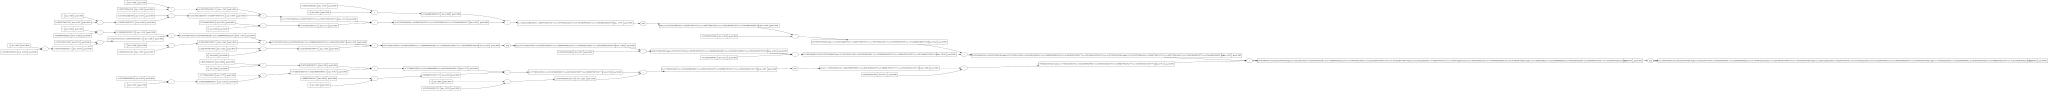

In [146]:
# 'out' is now a nested list: out[layer_index][neuron_index]
# To visualize, we must pick one specific neuron node
draw_dot_n(out[0])

[0.9510804207476622, -0.18421000689838962, 1, (-0.18421000689838962*1), -0.7772806104206513, (-0.7772806104206513+(-0.18421000689838962*1)), 5, 0.887816046294025, (0.887816046294025*5), ((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5)), 7, 0.8898887596129417, (0.8898887596129417*7), (((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7)), -0.025363060180112917, 9, (-0.025363060180112917*9), ((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)), tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9))), (0.9510804207476622*tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)))), 0.3091352339045468, 7, -0.9094632053195832, (-0.9094632053195832*7), 5, -0.29898909309218213, (-0.29898909309218213*5), 0.357612495147016

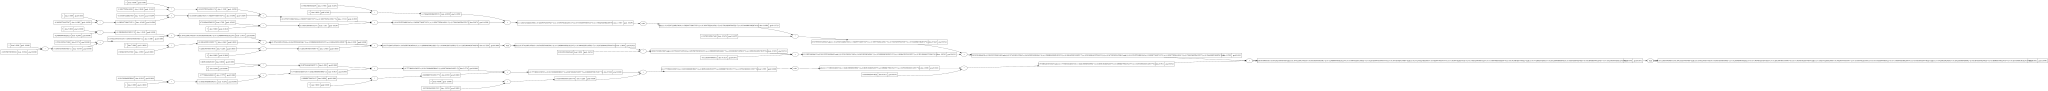

In [147]:
# Trigger backpropagation on the first output neuron
out[0].backward()

# Redraw the graph to see the updated gradients for all weights and biases
draw_dot_n(out[0])

[0.9510804207476622, -0.18421000689838962, 1, (-0.18421000689838962*1), -0.7772806104206513, (-0.7772806104206513+(-0.18421000689838962*1)), 5, 0.887816046294025, (0.887816046294025*5), ((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5)), 7, 0.8898887596129417, (0.8898887596129417*7), (((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7)), -0.025363060180112917, 9, (-0.025363060180112917*9), ((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)), tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9))), (0.9510804207476622*tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)))), 0.3091352339045468, 7, -0.9094632053195832, (-0.9094632053195832*7), 5, -0.29898909309218213, (-0.29898909309218213*5), 0.357612495147016

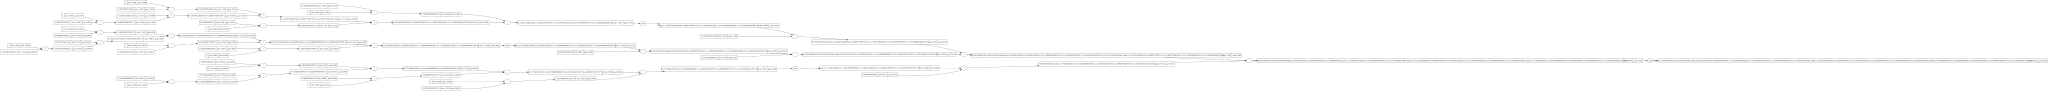

In [148]:
# Perform backpropagation on the first output neuron
out[0].backward()

# Visualize the graph again to see the updated gradients
draw_dot_n(out[0])

[0.9510804207476622, -0.18421000689838962, 1, (-0.18421000689838962*1), -0.7772806104206513, (-0.7772806104206513+(-0.18421000689838962*1)), 5, 0.887816046294025, (0.887816046294025*5), ((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5)), 7, 0.8898887596129417, (0.8898887596129417*7), (((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7)), -0.025363060180112917, 9, (-0.025363060180112917*9), ((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)), tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9))), (0.9510804207476622*tanh(((((-0.7772806104206513+(-0.18421000689838962*1))+(0.887816046294025*5))+(0.8898887596129417*7))+(-0.025363060180112917*9)))), 0.3091352339045468, 7, -0.9094632053195832, (-0.9094632053195832*7), 5, -0.29898909309218213, (-0.29898909309218213*5), 0.357612495147016

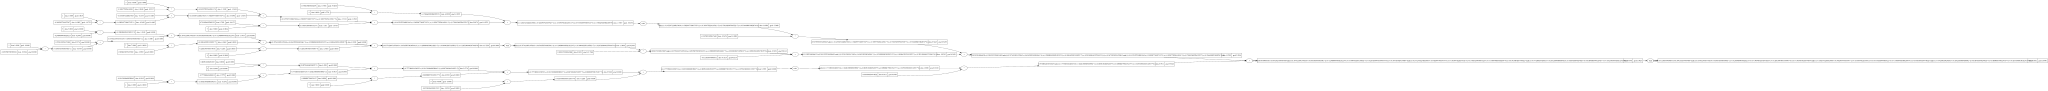

In [149]:
# 1. Run backpropagation on the output
out[0].backward()

# 2. Redraw the graph to see the gradients flow back to weights and biases
draw_dot_n(out[0])

In [150]:
# @title
a = [1, 2, 3]
b = ['a', 'b', 'c']

# Using zip() directly
zip_object = zip(a, b)
print(f"Type of zip_object: {type(zip_object)}")
print("Iterating over zip_object (first time):")
for item in zip_object:
    print(item)

print("\nTrying to iterate over zip_object again (it's exhausted):")
for item in zip_object:
    print(item) # This loop will not print anything

# Using list(zip())
list_from_zip = list(zip(a, b))
print(f"\nType of list_from_zip: {type(list_from_zip)}")
print("Iterating over list_from_zip (first time):")
for item in list_from_zip:
    print(item)

print("\nIterating over list_from_zip again (it still works):")
for item in list_from_zip:
    print(item)


Type of zip_object: <class 'zip'>
Iterating over zip_object (first time):
(1, 'a')
(2, 'b')
(3, 'c')

Trying to iterate over zip_object again (it's exhausted):

Type of list_from_zip: <class 'list'>
Iterating over list_from_zip (first time):
(1, 'a')
(2, 'b')
(3, 'c')

Iterating over list_from_zip again (it still works):
(1, 'a')
(2, 'b')
(3, 'c')
